In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [38]:
df = pd.read_csv("..//data/spotify_churn_dataset.csv")

#Drop ID
df = df.drop(columns=["user_id"])

#encoded categorical variables
df = pd.get_dummies(df, drop_first=True)

In [39]:
x = df.drop("is_churned", axis=1)
y = df["is_churned"]
#define x & y 

In [40]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
#train/test split

In [41]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
#scale

In [42]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)

model.fit(x_train_scaled,  y_train)
#train logistic regression

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [43]:
y_pred = model.predict(x_test_scaled)

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(x_test_scaled)[:,1]))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
#evaluate

              precision    recall  f1-score   support

           0       0.77      0.51      0.61      1200
           1       0.27      0.54      0.36       400

    accuracy                           0.52      1600
   macro avg       0.52      0.52      0.49      1600
weighted avg       0.64      0.52      0.55      1600

ROC-AUC: 0.52240625
Confusion Matrix
[[615 585]
 [185 215]]


In [44]:
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

feature_importance.head(10)
#interpret coefficients

,Feature,Coefficient
4,ads_listened_per_week,0.090399
5,offline_listening,0.067076
2,songs_played_per_day,0.039767
3,skip_rate,0.033821
12,country_PK,0.024775
9,country_DE,0.020911
10,country_FR,0.019715
7,gender_Other,0.005152
0,age,-0.000555
1,listening_time,-0.003829


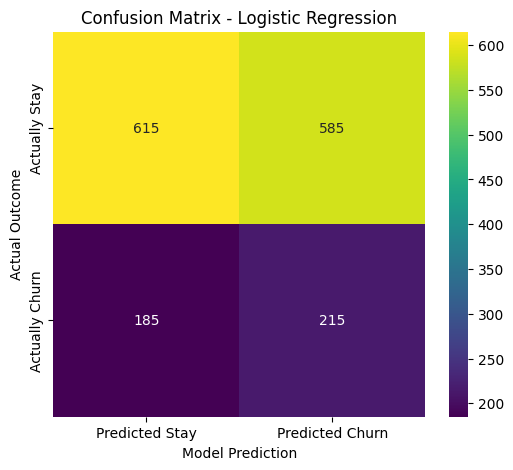

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix values
cm = confusion_matrix(y_test, y_pred)

# Create labeled heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='viridis',
            xticklabels=["Predicted Stay", "Predicted Churn"],
            yticklabels=["Actually Stay", "Actually Churn"])

plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual Outcome")
plt.xlabel("Model Prediction")

plt.show()

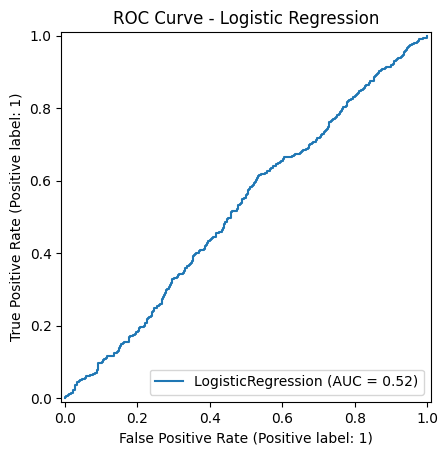

In [35]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, x_test_scaled, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.show()